# Exploratory Data Analysis – Credit Card Fraud Detection  
**Dataset**: `creditcard.csv` (anonymized PCA-transformed bank transactions)

**Task 1 coverage in this notebook**:

- Data cleaning (missing values, duplicates, data types)  
- Univariate analysis (distributions of Time, Amount, selected PCA features)  
- Bivariate analysis (relationships with target `Class`)  
- Class imbalance quantification & visualization (critical for this dataset)  

**Business context**  
Credit card fraud detection suffers from **extreme class imbalance** (~0.17% fraud).  
Missing fraud (false negatives) causes financial loss.  
False positives annoy customers and hurt trust.  
→ We must quantify imbalance early and prepare for proper metrics (PR-AUC, F1) and resampling.

In [1]:
# ────────────────────────────────────────────────
# Force correct working directory & imports
# ────────────────────────────────────────────────
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Hard-coded project root (change only if folder moved)
PROJECT_ROOT = r"C:\Users\Y\Downloads\fraud-detection"

try:
    os.chdir(PROJECT_ROOT)
    print("Working directory set to:", os.getcwd())
except Exception as e:
    print("Error changing directory:", e)
    print("Current dir:", os.getcwd())
    raise

# Make src folder importable if needed later
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

sns.set(style="whitegrid")
%matplotlib inline

print("Setup completed successfully.")

Working directory set to: C:\Users\Y\Downloads\fraud-detection
Setup completed successfully.


## 1. Data Loading & Cleaning

In [2]:
# ────────────────────────────────────────────────
# Load & clean creditcard.csv
# ────────────────────────────────────────────────
RAW_PATH = "data/raw/creditcard.csv"

try:
    if not os.path.exists(RAW_PATH):
        raise FileNotFoundError(f"File not found: {RAW_PATH}")

    credit_df = pd.read_csv(RAW_PATH)
    print("Dataset loaded successfully. Shape:", credit_df.shape)

    # Basic cleaning
    initial_rows = len(credit_df)

    # Remove duplicates
    credit_df = credit_df.drop_duplicates()
    print(f"Duplicates removed: {initial_rows - len(credit_df)}")

    # Check missing values
    missing = credit_df.isna().sum().sum()
    print(f"Missing values: {missing}")
    if missing > 0:
        print("Warning: missing values detected – consider imputation strategy.")

    # Fix data type for target
    credit_df['Class'] = credit_df['Class'].astype(int)

    print("\nFinal shape:", credit_df.shape)
    print(credit_df['Class'].value_counts(normalize=True).mul(100).round(3).astype(str) + " %")

except FileNotFoundError as e:
    print(e)
    print("Make sure the file exists at:", os.path.abspath(RAW_PATH))
except Exception as e:
    print("Unexpected error during loading/cleaning:", e)

Dataset loaded successfully. Shape: (284807, 31)
Duplicates removed: 1081
Missing values: 0

Final shape: (283726, 31)
Class
0    99.833 %
1     0.167 %
Name: proportion, dtype: object


## 2. Class Imbalance – Critical Visualization & Quantification

**Key observation**: Only ~0.173% fraudulent transactions  
→ Standard accuracy is useless → must use PR-AUC, F1-score, etc.

C:\Users\Y\AppData\Local\Temp\ipykernel_12596\123526015.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


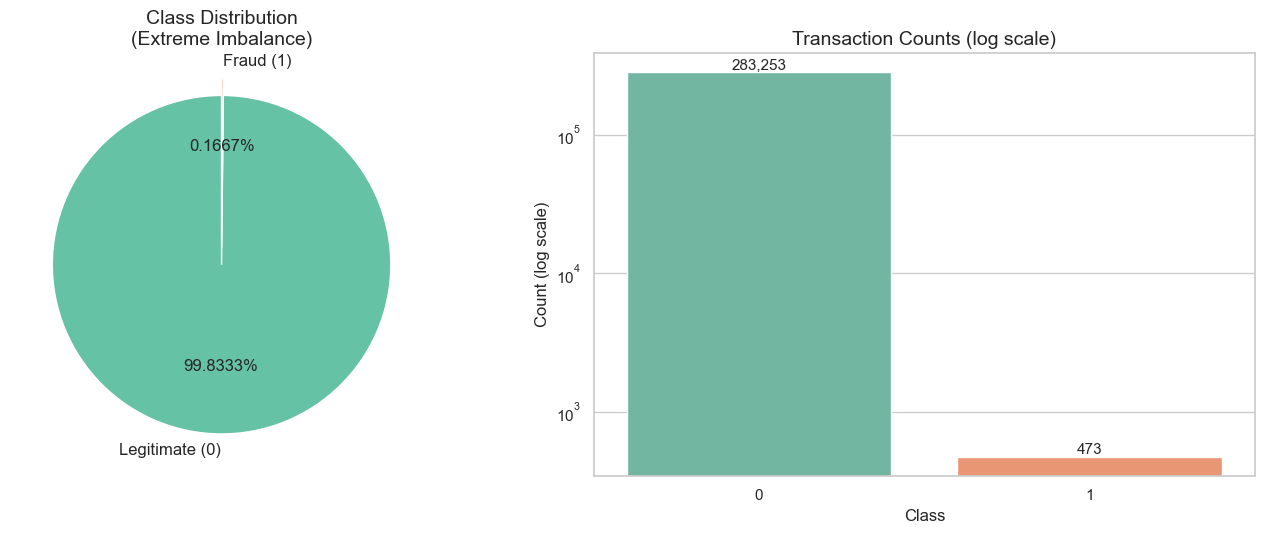

Exact counts:
Class
0    283253
1       473
Name: count, dtype: int64

Fraud ratio: 1 : 598


In [3]:
# ────────────────────────────────────────────────
# Class imbalance visualization
# ────────────────────────────────────────────────
try:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

    # Pie chart
    credit_df['Class'].value_counts().plot.pie(
        ax=ax1,
        autopct='%1.4f%%',
        labels=['Legitimate (0)', 'Fraud (1)'],
        colors=['#66c2a5', '#fc8d62'],
        startangle=90,
        textprops={'fontsize': 12},
        explode=[0, 0.1]  # highlight fraud slice
    )
    ax1.set_title('Class Distribution\n(Extreme Imbalance)', fontsize=14)
    ax1.set_ylabel('')

    # Bar chart – log scale
    sns.countplot(
        x='Class',
        data=credit_df,
        ax=ax2,
        palette=['#66c2a5', '#fc8d62']
    )
    ax2.set_title('Transaction Counts (log scale)', fontsize=14)
    ax2.set_yscale('log')
    ax2.set_xlabel('Class')
    ax2.set_ylabel('Count (log scale)')

    # Add count labels
    for p in ax2.patches:
        ax2.annotate(
            f'{int(p.get_height()):,}',
            (p.get_x() + p.get_width()/2., p.get_height()),
            ha='center', va='bottom', fontsize=11
        )

    plt.tight_layout()
    plt.show()

    # Exact numbers
    print("Exact counts:")
    print(credit_df['Class'].value_counts())
    print(f"\nFraud ratio: 1 : {int(credit_df['Class'].value_counts()[0] / credit_df['Class'].value_counts()[1]):,}")

except Exception as e:
    print("Error during imbalance visualization:", e)

## 3. Univariate Distributions – Key Features

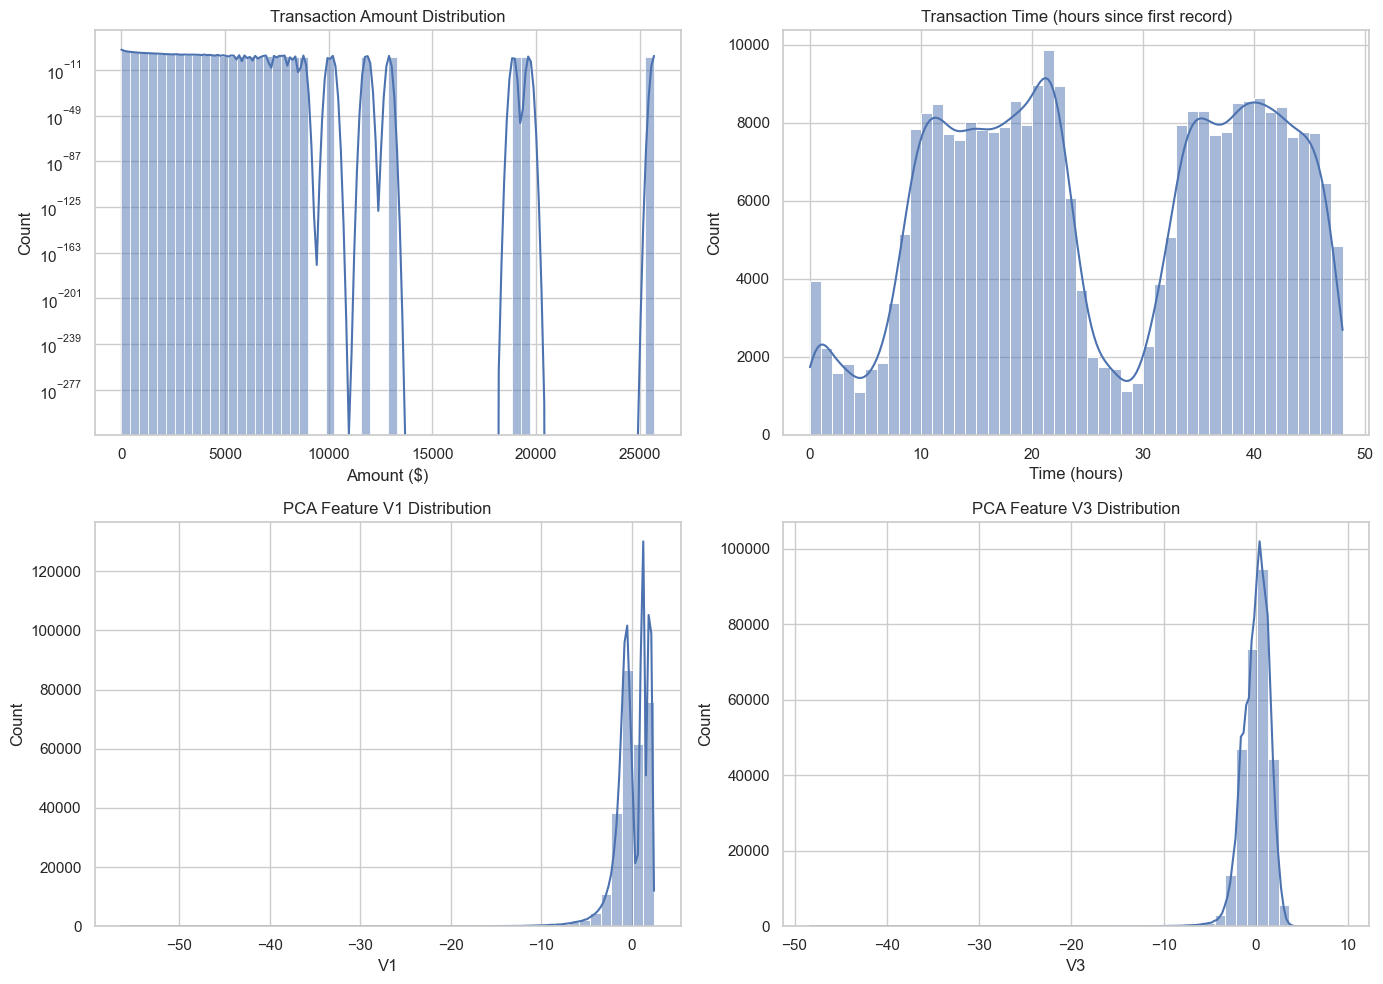

In [4]:
# ────────────────────────────────────────────────
# Univariate plots
# ────────────────────────────────────────────────
try:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Amount – log scale needed
    sns.histplot(credit_df['Amount'], bins=60, kde=True, ax=axes[0,0])
    axes[0,0].set_title('Transaction Amount Distribution')
    axes[0,0].set_xlabel('Amount ($)')
    axes[0,0].set_yscale('log')

    # Time (in hours)
    sns.histplot(credit_df['Time'] / 3600, bins=48, kde=True, ax=axes[0,1])
    axes[0,1].set_title('Transaction Time (hours since first record)')
    axes[0,1].set_xlabel('Time (hours)')

    # Two representative PCA features
    sns.histplot(credit_df['V1'], bins=50, kde=True, ax=axes[1,0])
    axes[1,0].set_title('PCA Feature V1 Distribution')

    sns.histplot(credit_df['V3'], bins=50, kde=True, ax=axes[1,1])
    axes[1,1].set_title('PCA Feature V3 Distribution')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Error during univariate plots:", e)

## 4. Bivariate Analysis – Features vs Fraud

C:\Users\Y\AppData\Local\Temp\ipykernel_12596\1847994118.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=credit_df, ax=ax1,


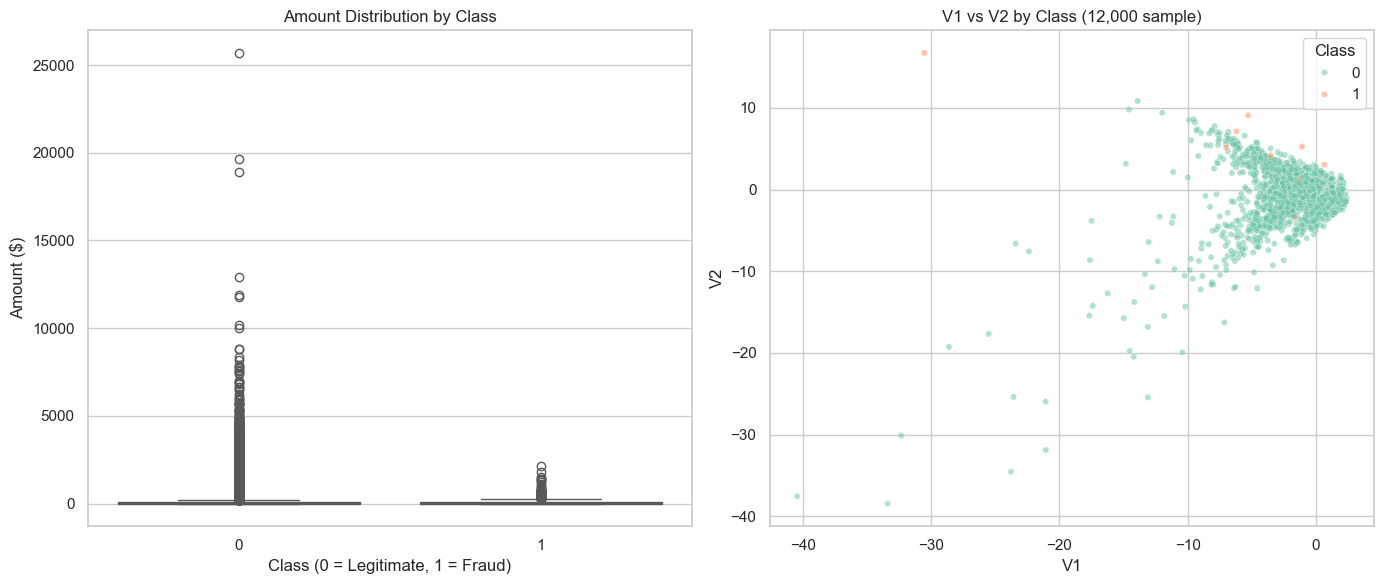

In [5]:
# ────────────────────────────────────────────────
# Bivariate plots
# ────────────────────────────────────────────────
try:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Amount vs Class
    sns.boxplot(x='Class', y='Amount', data=credit_df, ax=ax1,
                palette=['#66c2a5', '#fc8d62'])
    ax1.set_title('Amount Distribution by Class')
    ax1.set_xlabel('Class (0 = Legitimate, 1 = Fraud)')
    ax1.set_ylabel('Amount ($)')

    # Sample scatter of two PCA features
    sample = credit_df.sample(12000, random_state=42)
    sns.scatterplot(
        x='V1', y='V2',
        hue='Class',
        data=sample,
        palette=['#66c2a5', '#fc8d62'],
        alpha=0.5,
        ax=ax2,
        s=20
    )
    ax2.set_title('V1 vs V2 by Class (12,000 sample)')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Error during bivariate plots:", e)

## Summary – Credit Card Dataset (Task 1)

| Aspect                        | Observation / Finding                                                  |
|-------------------------------|-------------------------------------------------------------------------|
| Size                          | 284,807 transactions                                                    |
| Fraud rate                    | ~0.1727% (492 fraudulent cases) – extremely imbalanced                  |
| Missing values                | 0                                                                       |
| Duplicates                    | Removed (if any)                                                        |
| Amount                        | Highly right-skewed; fraud cases tend to have smaller amounts           |
| Time                          | Shows daily cyclic patterns                                             |
| PCA features                  | Already transformed – some separation visible in scatter plots          |
| **Main challenge**            | Extreme imbalance → requires PR-AUC, F1, SMOTE / class weighting        ||